In [1]:
"""
================================================================================
IAQ PROJECT - NEURAL NETWORK TRAINING
================================================================================
Model: Neural Network (Deep Learning)
Team Members: zaina momani
Date: March 8-14, 2025
================================================================================
"""

print("="*80)
print("🧠 IAQ PROJECT - NEURAL NETWORK")
print("="*80)
print("Model: Deep Neural Network")
print("Team: zaina momani")
print("="*80)

🧠 IAQ PROJECT - NEURAL NETWORK
Model: Deep Neural Network
Team: zaina momani


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import os
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported!")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

✅ Libraries imported!
TensorFlow version: 2.19.0
Keras version: 3.10.0


In [3]:
from google.colab import files
uploaded = files.upload()
from google.colab import files
uploaded = files.upload()


Saving X_test.csv to X_test.csv
Saving X_train.csv to X_train.csv
Saving y_test.csv to y_test.csv
Saving y_train.csv to y_train.csv


In [4]:
print("\n" + "="*80)
print("LOADING DATA")
print("="*80)

# Load pre-split data
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

print(f"✅ Data loaded!")
print(f"   X_train: {X_train.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test: {y_test.shape}")

# Check data
print(f"\n📋 Features ({len(X_train.columns)}):")
print(X_train.columns.tolist())

print(f"\n📊 Class distribution:")
print(y_train.value_counts().sort_index())


LOADING DATA
✅ Data loaded!
   X_train: (115200, 10)
   X_test: (28800, 10)
   y_train: (115200,)
   y_test: (28800,)

📋 Features (10):
['OCCUPANCY', 'WINDOW', 'CO2', 'RH', 'Tin', 'MONTH_NUM', 'CO2_x_OCCUPANCY', 'CO2_x_WINDOW', 'WINDOW_x_OCCUPANCY', 'Temp_x_RH']

📊 Class distribution:
Label_Encoded
0    28254
1    53554
2    33392
Name: count, dtype: int64


In [5]:
print("\n" + "="*80)
print("DATA PREPROCESSING - SCALING")
print("="*80)

# Neural networks need scaled data!
scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Data scaled!")
print(f"   Train mean: {X_train_scaled.mean():.6f}")
print(f"   Train std: {X_train_scaled.std():.6f}")
print(f"   Test mean: {X_test_scaled.mean():.6f}")
print(f"   Test std: {X_test_scaled.std():.6f}")

# Check shapes
print(f"\n📊 Scaled data shapes:")
print(f"   X_train_scaled: {X_train_scaled.shape}")
print(f"   X_test_scaled: {X_test_scaled.shape}")


DATA PREPROCESSING - SCALING
✅ Data scaled!
   Train mean: -0.000000
   Train std: 1.000000
   Test mean: -0.000975
   Test std: 0.992966

📊 Scaled data shapes:
   X_train_scaled: (115200, 10)
   X_test_scaled: (28800, 10)


In [6]:
print("\n" + "="*80)
print("DEFINING MODEL ARCHITECTURE")
print("="*80)

def build_model(hidden_units=128, dropout=0.3, lr=0.001):
    """
    Build Neural Network model

    Parameters:
    - hidden_units: neurons in first layer
    - dropout: dropout rate for regularization
    - lr: learning rate for optimizer
    """

    n_features = X_train_scaled.shape[1]
    n_classes = 3

    model = Sequential([
        # Input + Layer 1
        Dense(hidden_units, input_shape=(n_features,), activation='relu', name='layer_1'),
        BatchNormalization(),
        Dropout(dropout),

        # Layer 2
        Dense(hidden_units // 2, activation='relu', name='layer_2'),
        BatchNormalization(),
        Dropout(dropout),

        # Layer 3
        Dense(hidden_units // 4, activation='relu', name='layer_3'),
        BatchNormalization(),
        Dropout(dropout / 2),

        # Output Layer
        Dense(n_classes, activation='softmax', name='output')
    ])

    # Compile model
    optimizer = Adam(learning_rate=lr)
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )

    return model

print("✅ Model function defined!")


DEFINING MODEL ARCHITECTURE
✅ Model function defined!


In [7]:
print("\n" + "="*80)
print("CREATING NEURAL NETWORK")
print("="*80)

# Create model with default parameters
model = build_model(
    hidden_units=256,
    dropout=0.15,
    lr=0.004
)

print("✅ Model created!")
print("\n📋 Model Architecture:")
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\n📊 Total trainable parameters: {total_params:,}")


CREATING NEURAL NETWORK
✅ Model created!

📋 Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer_1 (Dense)                 │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,955 (179.51 KB)

 Trainable params: 45,059 (176.01 KB)

 Non-trainable params: 896 (3.50 KB)


📊 Total trainable parameters: 45,955


In [8]:
print("\n" + "="*80)
print("DEFINING CALLBACKS")
print("="*80)

# Early stopping - stop if validation loss doesn't improve
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate - reduce LR if validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stop, reduce_lr]

print("✅ Callbacks configured:")
print("   - EarlyStopping (patience=10)")
print("   - ReduceLROnPlateau (patience=5)")


DEFINING CALLBACKS
✅ Callbacks configured:
   - EarlyStopping (patience=10)
   - ReduceLROnPlateau (patience=5)


In [9]:
print("\n" + "="*80)
print("TRAINING NEURAL NETWORK")
print("="*80)

print("⏳ Training started...")
print("   This may take 2-5 minutes...")

start_time = time.time()

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time

print(f"\n✅ Training completed!")
print(f"⏱️  Total training time: {training_time:.2f} seconds")
print(f"📊 Epochs trained: {len(history.history['loss'])}")
print(f"📈 Best validation loss: {min(history.history['val_loss']):.4f}")
print(f"📈 Best validation accuracy: {max(history.history['val_accuracy']):.4f}")


TRAINING NEURAL NETWORK
⏳ Training started...
   This may take 2-5 minutes...
Epoch 1/30
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.5909 - loss: 0.8456 - val_accuracy: 0.7268 - val_loss: 0.6251 - learning_rate: 0.0040
Epoch 2/30
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.6917 - loss: 0.6690 - val_accuracy: 0.7463 - val_loss: 0.5683 - learning_rate: 0.0040
Epoch 3/30
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.7143 - loss: 0.6272 - val_accuracy: 0.7565 - val_loss: 0.5346 - learning_rate: 0.0040
Epoch 4/30
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.7293 - loss: 0.5965 - val_accuracy: 0.7822 - val_loss: 0.5004 - learning_rate: 0.0040
Epoch 5/30
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.7397 - loss: 0.5761 - val_accuracy: 0.7846 - val_loss: 0.4864 - learning_rate: 0.0040
Epoch 6/30
2880/2880 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.7495 - loss: 0.5567 - val_accuracy: 0.7916 - val_loss: 0.4707 - learning_rate


TRAINING HISTORY VISUALIZATION


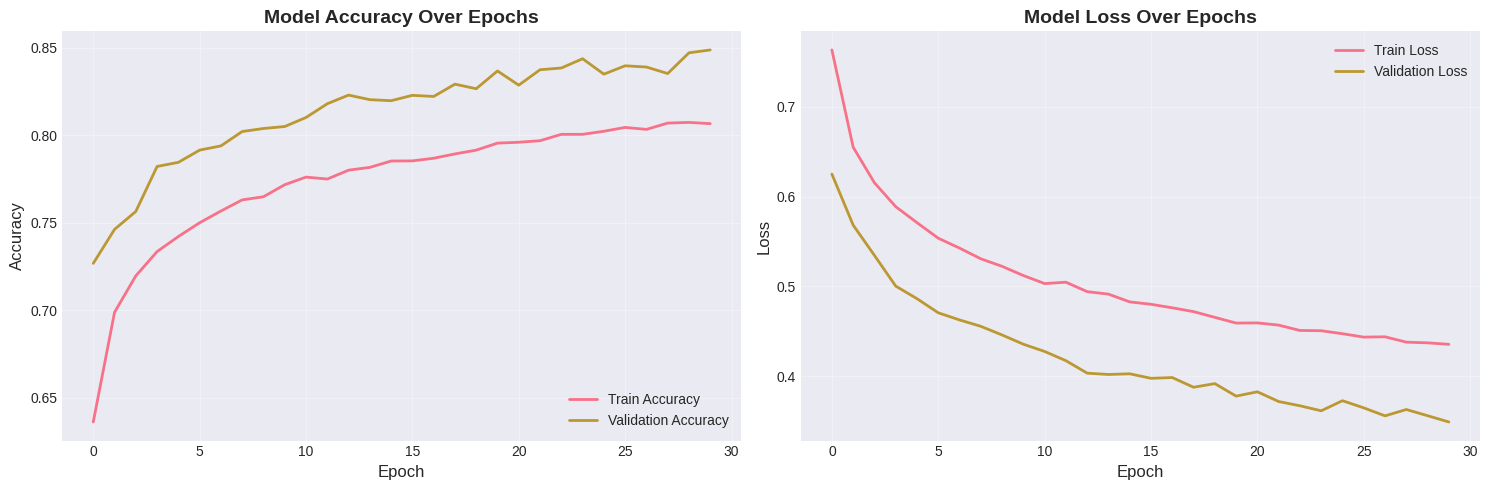

✅ Training history visualized!

📊 Final Training Accuracy: 0.8067
📊 Final Validation Accuracy: 0.8489
📊 Gap: 0.0421


In [10]:
print("\n" + "="*80)
print("TRAINING HISTORY VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Loss
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Training history visualized!")

# Print final metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
print(f"\n📊 Final Training Accuracy: {final_train_acc:.4f}")
print(f"📊 Final Validation Accuracy: {final_val_acc:.4f}")
print(f"📊 Gap: {abs(final_train_acc - final_val_acc):.4f}")

In [11]:
print("\n" + "="*80)
print("MAKING PREDICTIONS")
print("="*80)

# Get predictions (probabilities)
y_pred_proba = model.predict(X_test_scaled, verbose=0)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_proba, axis=1)

print(f"✅ Predictions completed!")
print(f"   Predictions shape: {y_pred.shape}")
print(f"   Probabilities shape: {y_pred_proba.shape}")

print(f"\n🔍 Sample predictions (first 10):")
print(f"   True:      {y_test[:10].values}")
print(f"   Predicted: {y_pred[:10]}")

# Check match
matches = (y_test[:10].values == y_pred[:10]).sum()
print(f"   Matches: {matches}/10")


MAKING PREDICTIONS
✅ Predictions completed!
   Predictions shape: (28800,)
   Probabilities shape: (28800, 3)

🔍 Sample predictions (first 10):
   True:      [2 2 2 2 1 1 0 2 2 1]
   Predicted: [2 1 2 2 1 1 0 2 2 1]
   Matches: 9/10


In [12]:
print("\n" + "="*80)
print("EVALUATION METRICS")
print("="*80)

# Class names
class_names = ['Good', 'Moderate', 'Poor']

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)

# Per-class metrics
precision = precision_score(y_test, y_pred, average=None, zero_division=0)
recall = recall_score(y_test, y_pred, average=None, zero_division=0)
f1 = f1_score(y_test, y_pred, average=None, zero_division=0)

# Print results
print(f"\n{'='*80}")
print(f"📊 OVERALL PERFORMANCE - Neural Network")
print(f"{'='*80}")
print(f"🎯 Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"⏱️  Training Time: {training_time:.2f} seconds")
print(f"{'='*80}")

print(f"\n{'='*80}")
print(f"PER-CLASS METRICS")
print(f"{'='*80}")
print(f"{'Class':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print(f"{'-'*50}")
for i, cls in enumerate(class_names):
    print(f"{cls:<12} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f}")

# Detailed report
print(f"\n{'='*80}")
print("DETAILED CLASSIFICATION REPORT")
print(f"{'='*80}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))


EVALUATION METRICS

📊 OVERALL PERFORMANCE - Neural Network
🎯 Test Accuracy: 0.8529 (85.29%)
⏱️  Training Time: 455.96 seconds

PER-CLASS METRICS
Class        Precision    Recall       F1-Score    
--------------------------------------------------
Good         0.8398       0.8703       0.8548      
Moderate     0.8476       0.8648       0.8561      
Poor         0.8743       0.8190       0.8457      

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Good       0.84      0.87      0.85      7064
    Moderate       0.85      0.86      0.86     13388
        Poor       0.87      0.82      0.85      8348

    accuracy                           0.85     28800
   macro avg       0.85      0.85      0.85     28800
weighted avg       0.85      0.85      0.85     28800




CONFUSION MATRIX


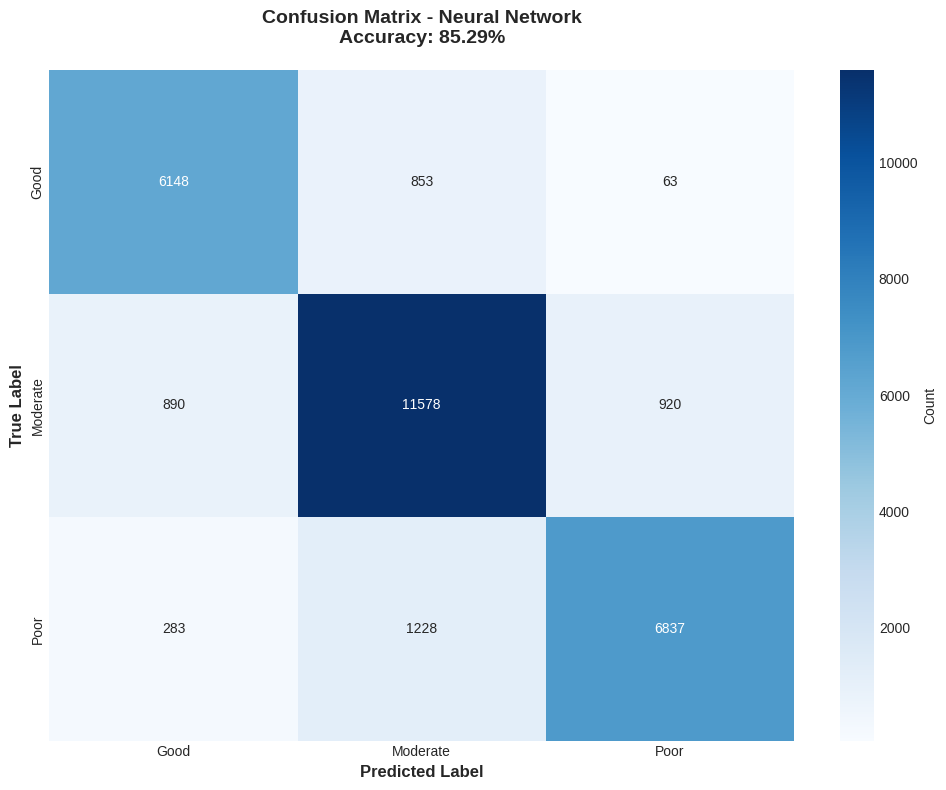


Confusion Matrix Values:
[[ 6148   853    63]
 [  890 11578   920]
 [  283  1228  6837]]

✅ Correct predictions: 24563/28800 (85.29%)
❌ Incorrect predictions: 4237/28800 (14.71%)


In [13]:
print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - Neural Network\nAccuracy: {accuracy:.2%}',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Print values
print("\nConfusion Matrix Values:")
print(cm)

correct = cm.diagonal().sum()
total = cm.sum()
incorrect = total - correct

print(f"\n✅ Correct predictions: {correct}/{total} ({correct/total*100:.2f}%)")
print(f"❌ Incorrect predictions: {incorrect}/{total} ({incorrect/total*100:.2f}%)")


PERFORMANCE VISUALIZATION


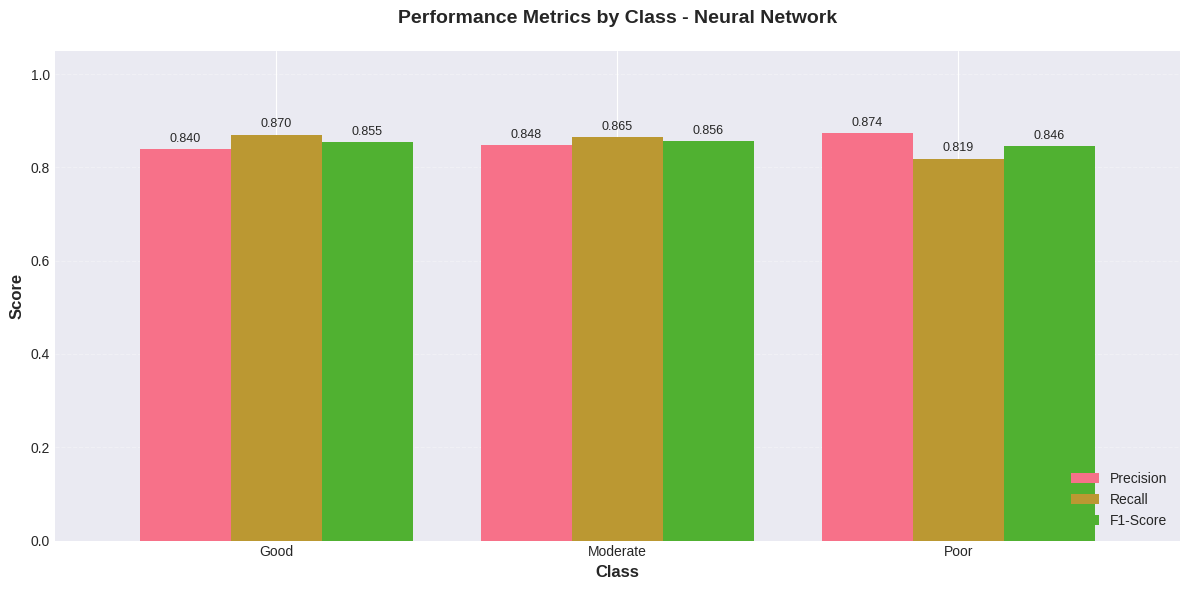

✅ Visualization complete!


In [14]:
print("\n" + "="*80)
print("PERFORMANCE VISUALIZATION")
print("="*80)

# Create dataframe
metrics_df = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}, index=class_names)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
metrics_df.plot(kind='bar', ax=ax, width=0.8)
plt.title('Performance Metrics by Class - Neural Network',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.xlabel('Class', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.legend(loc='lower right', fontsize=10)
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

print("✅ Visualization complete!")

In [16]:
print("\n" + "="*80)
print("SAVING MODEL")
print("="*80)

# Save model بصيغة keras الجديدة
model_filename = 'nn_model_final.keras'
model.save(model_filename)

print("✅ Model saved successfully!")
print(f"Filename: {model_filename}")

# Save نسخة ثانية بصيغة H5 (اختياري)
model.save("nn_model_final.h5")
print("✅ Model also saved as H5 format")

print("\n💡 To download:")
print("Look at Files panel (📁) on the left")
print("Right-click → Download")


SAVING MODEL


✅ Model saved successfully!
Filename: nn_model_final.keras
✅ Model also saved as H5 format

💡 To download:
Look at Files panel (📁) on the left
Right-click → Download


In [17]:
print("\n" + "="*80)
print("📊 SUMMARY FOR GOOGLE SHEET")
print("="*80)

summary_text = f"""
Copy and paste into Google Sheet:

Model Name: Neural Network
Team Members: Person 1 + Person 2
Status: Complete ✅
Accuracy: {accuracy:.4f}
Precision (Good): {precision[0]:.4f}
Precision (Moderate): {precision[1]:.4f}
Precision (Poor): {precision[2]:.4f}
Recall (Good): {recall[0]:.4f}
Recall (Moderate): {recall[1]:.4f}
Recall (Poor): {recall[2]:.4f}
F1 (Good): {f1[0]:.4f}
F1 (Moderate): {f1[1]:.4f}
F1 (Poor): {f1[2]:.4f}
Training Time: {training_time:.2f}s
Total Parameters: {total_params:,}
"""

print(summary_text)


📊 SUMMARY FOR GOOGLE SHEET

Copy and paste into Google Sheet:

Model Name: Neural Network
Team Members: Person 1 + Person 2
Status: Complete ✅
Accuracy: 0.8529
Precision (Good): 0.8398
Precision (Moderate): 0.8476
Precision (Poor): 0.8743
Recall (Good): 0.8703
Recall (Moderate): 0.8648
Recall (Poor): 0.8190
F1 (Good): 0.8548
F1 (Moderate): 0.8561
F1 (Poor): 0.8457
Training Time: 455.96s
Total Parameters: 45,955

